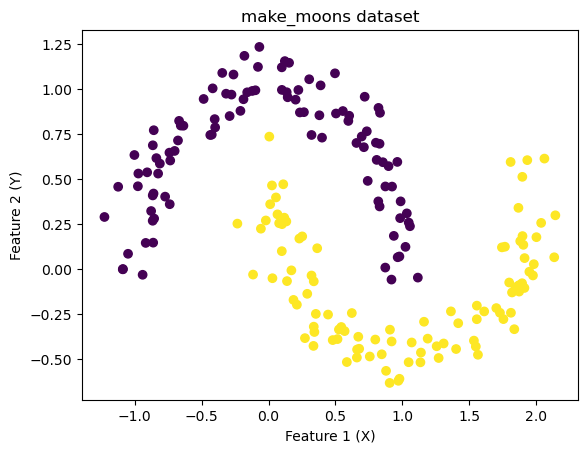

(200, 1)


In [12]:
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

X_train, Y_train = make_moons(n_samples=200, noise=0.1, random_state=42)

plt.scatter(X_train[:,0], X_train[:,1],c=Y_train)
plt.xlabel("Feature 1 (X)")
plt.ylabel("Feature 2 (Y)")
plt.title("make_moons dataset")
plt.show()
Y_train = Y_train.reshape([X_train.shape[0],1])
print(Y_train.shape)

# Classe logistique

In [13]:
import numpy as np

class LogisticRegression:

    def __init__(self, n_features, ridge_lambda=0):
        self.w = np.random.randn(n_features, 1)
        self.costs = []
        self.lamda = ridge_lambda

    # SIGMOID

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))


    # PREDICTION (probabilité)

    def predict_proba(self, X):
        return self.sigmoid(X @ self.w)


    # PREDICTION (classe)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


    # COST FUNCTION (log loss + ridge)

    def cost(self, X, y):
        # m = len(y)

        # y_hat = self.predict_proba(X)

        # # éviter log(0)
        # eps = 1e-15
        # y_hat = np.clip(y_hat, eps, 1 - eps)

        # log_loss = -np.mean(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))

        # ridge = self.lamda * np.sum(self.w ** 2)

        # return log_loss + ridge / (2*m)

        m = X.shape[0]

        # prédiction
        y_hat = self.sigmoid(X @ self.w)

        # éviter log(0)
        eps = 1e-15
        y_hat = np.clip(y_hat, eps, 1 - eps)

        # loss matricielle
        loss = - (1/m) * (
            y.T @ np.log(y_hat) +
            (1 - y).T @ np.log(1 - y_hat)
        )

        return loss.item()
    
    # GRADIENT

    def grad(self, X, y):
        m = len(y)

        y_hat = self.predict_proba(X)

        error = y_hat - y

        ridge = self.lamda * self.w

        return (1/m) * (X.T @ error + ridge)

    # GRADIENT DESCENT

    def descente_gradient(self, X, y, alpha, n_iterations):

        for i in range(n_iterations):
            self.w = self.w - alpha * self.grad(X, y)
            self.costs.append(self.cost(X, y))

In [14]:
lr = LogisticRegression(X_train.shape[1])
print('avant train : ' + str(lr.w))
lr.descente_gradient(X_train,Y_train,alpha=0.1,n_iterations=1000)

print('apres train :' + str(lr.w) )



avant train : [[1.105603  ]
 [0.90945945]]
apres train :[[ 1.37933851]
 [-3.69249651]]


In [15]:
prediction = lr.predict(X_train)
print('accuracy score : ' + str(accuracy_score(Y_train,prediction)))


accuracy score : 0.86
